#### Import Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,f1_score,confusion_matrix,recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import LogisticRegression

In [53]:
df = pd.read_csv("breast-cancer.csv")
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Making Target Variable 

In [54]:
diagnose_value = df.diagnosis.unique()
print(f"Value of diagnosis: {diagnose_value}")
print("In Logistic Regression, the value of diagnosis is binary, i.e., 0 or 1.")
print("It should be target variable , i.e., dependent variable.")

dict = {"M":1,"B":0}
df['diagnosis'] = df['diagnosis'].map(dict)
df.head()

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

Value of diagnosis: ['M' 'B']
In Logistic Regression, the value of diagnosis is binary, i.e., 0 or 1.
It should be target variable , i.e., dependent variable.


#### Checking NUll Values

id                         0.0
diagnosis                  0.0
radius_mean                0.0
texture_mean               0.0
perimeter_mean             0.0
area_mean                  0.0
smoothness_mean            0.0
compactness_mean           0.0
concavity_mean             0.0
concave points_mean        0.0
symmetry_mean              0.0
fractal_dimension_mean     0.0
radius_se                  0.0
texture_se                 0.0
perimeter_se               0.0
area_se                    0.0
smoothness_se              0.0
compactness_se             0.0
concavity_se               0.0
concave points_se          0.0
symmetry_se                0.0
fractal_dimension_se       0.0
radius_worst               0.0
texture_worst              0.0
perimeter_worst            0.0
area_worst                 0.0
smoothness_worst           0.0
compactness_worst          0.0
concavity_worst            0.0
concave points_worst       0.0
symmetry_worst             0.0
fractal_dimension_worst    0.0
dtype: f

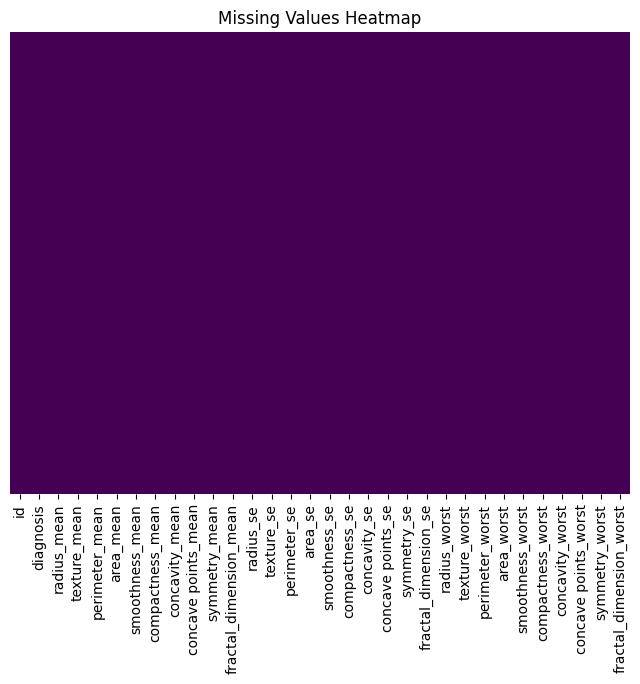

In [55]:
null_values = round(df.isnull().sum()/len(df)*100,3).sort_values()
print(null_values)
print("No null values")

plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

### Feature scaling

In [56]:
X = df.drop(columns=['diagnosis'])  
y = df['diagnosis']                 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# View scaled data
X_scaled_df.head()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,-0.236405,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,-0.236403,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,0.431741,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,0.432121,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,0.432201,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### Train Test Split

In [57]:
X_train,X_test,y_train,y_test =train_test_split(X_scaled_df,y,test_size=0.2,random_state=42)

model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)


#### Evaluation metrics 

In [58]:
confuse = confusion_matrix(y_test,y_pred)
accuracy = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
precise = precision_score(y_pred,y_test)
recall = recall_score(y_test,y_pred)

print("Confusion Matrix: ", confuse)
print("Accuracy: ", accuracy)
print("F1 Score: ", f1)
print("Precision: ", precise)
print("Recall: ", recall)


Confusion Matrix:  [[70  1]
 [ 2 41]]
Accuracy:  0.9736842105263158
F1 Score:  0.9647058823529412
Precision:  0.9534883720930233
Recall:  0.9534883720930233


#### Visualization 

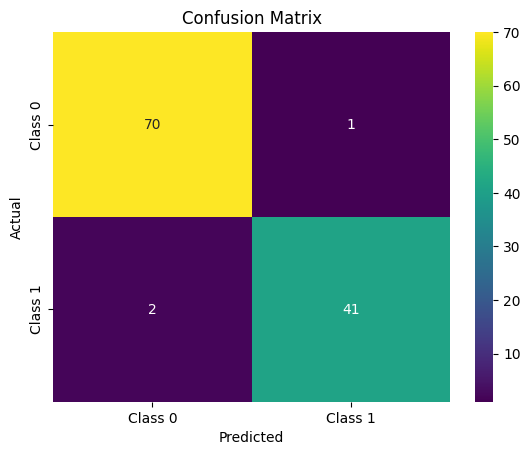

In [59]:

labels = ['Class 0', 'Class 1']  
sns.heatmap(confuse, annot=True, fmt='d', cmap='viridis', xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Boundaries

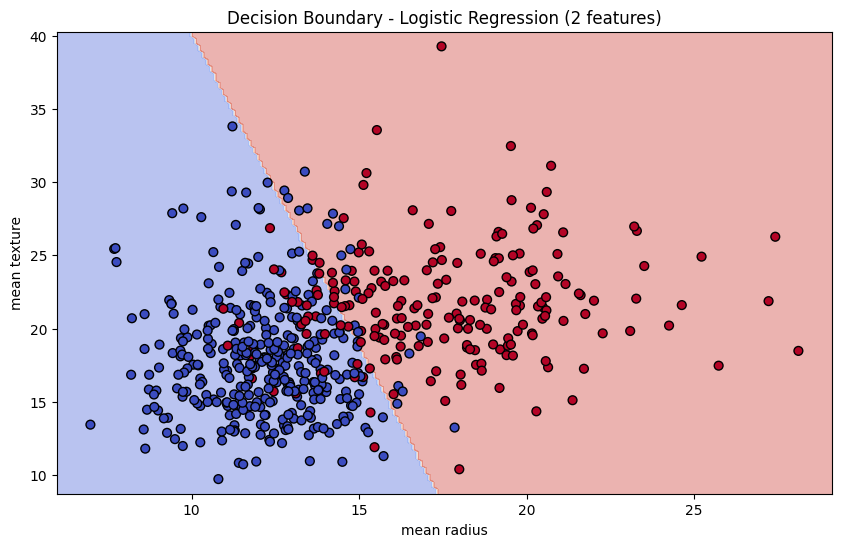

In [60]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data[:, [0, 1]]  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor='k', cmap='coolwarm')
    plt.title("Decision Boundary - Logistic Regression (2 features)")
    plt.xlabel("mean radius")
    plt.ylabel("mean texture")
    plt.show()

plot_decision_boundary(np.vstack((X_train, X_test)), np.hstack((y_train, y_test)), model)
